# Autoencoder Training Notebook (BatchNorm + Dropout Sweep)

This notebook runs a small BatchNorm + Dropout sweep on the shared `64x64` 5% test-defect dataset, selects the best dropout by validation loss, and then reuses that run for the same evaluation flow as the baseline notebook.


In [8]:
from pathlib import Path
import json
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, confusion_matrix, f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score
import torch
from torch.utils.data import DataLoader

cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
REPO_ROOT = None
for candidate in candidate_roots:
    if (candidate / "src" / "wafer_defect").exists() and (candidate / "configs").exists():
        REPO_ROOT = candidate
        break

if REPO_ROOT is None:
    raise RuntimeError("Could not locate repo root containing src/wafer_defect and configs/")

SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from wafer_defect.config import load_toml
from wafer_defect.data.wm811k import WaferMapDataset
from wafer_defect.models.autoencoder import ConvAutoencoder
from wafer_defect.scoring import absolute_error_map, squared_error_map, spatial_mean, topk_spatial_mean
from wafer_defect.training.autoencoder import run_autoencoder_epoch

In [9]:
RESOLUTION = "64"
EPOCHS_OVERRIDE = None
ANOMALY_SCORE_NAME = "topk_abs_mean"
TOPK_RATIO = 0.01
DROPOUT_SWEEP = [0.0, 0.05, 0.1, 0.2]
CONFIG_OPTIONS = {
    "64": REPO_ROOT / "configs/training/train_autoencoder_batchnorm_dropout.toml",
}
CONFIG_PATH = CONFIG_OPTIONS[RESOLUTION]
config = load_toml(CONFIG_PATH)
if EPOCHS_OVERRIDE is not None:
    config["training"]["epochs"] = int(EPOCHS_OVERRIDE)
base_output_dir = REPO_ROOT / config["run"]["output_dir"]
config


{'run': {'output_dir': 'artifacts/x64/autoencoder_batchnorm_dropout',
  'seed': 42},
 'data': {'metadata_csv': 'data/processed/x64/wm811k/metadata_50k_5pct.csv',
  'image_size': 64,
  'batch_size': 64,
  'num_workers': 0},
 'training': {'epochs': 50,
  'learning_rate': 0.001,
  'weight_decay': 0.0001,
  'device': 'auto',
  'early_stopping_patience': 5,
  'early_stopping_min_delta': 5e-05,
  'checkpoint_every': 5,
  'resume_from': ''},
 'model': {'type': 'autoencoder',
  'latent_dim': 128,
  'use_batchnorm': True,
  'dropout_prob': 0.1}}

In [10]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

def resolve_device(device_name: str) -> torch.device:
    if device_name == "auto":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return torch.device(device_name)

set_seed(int(config["run"]["seed"]))
device = resolve_device(config["training"]["device"])
device

device(type='cuda')

In [11]:
metadata_path = REPO_ROOT / config["data"]["metadata_csv"]
image_size = int(config["data"].get("image_size", 64))
metadata = pd.read_csv(metadata_path)

display(metadata.head())
display(metadata["split"].value_counts().rename_axis("split").to_frame("count"))
display(metadata["is_anomaly"].value_counts().rename_axis("is_anomaly").to_frame("count"))

,array_path,label,defect_type,is_anomaly,split,source_split,original_height,original_width
0,data/processed/x64/wm811k/arrays/wafer_0000000...,none,none,0,train,Training,25,27
1,data/processed/x64/wm811k/arrays/wafer_0000001...,none,none,0,train,Training,55,66
2,data/processed/x64/wm811k/arrays/wafer_0000002...,none,none,0,train,Test,33,29
3,data/processed/x64/wm811k/arrays/wafer_0000003...,none,none,0,train,Training,25,26
4,data/processed/x64/wm811k/arrays/wafer_0000004...,none,none,0,train,Test,39,37


,count
split,
train,40000
test,5250
val,5000


,count
is_anomaly,
0,50000
1,250


In [12]:
train_dataset = WaferMapDataset(metadata_path, split="train", image_size=image_size)
val_dataset = WaferMapDataset(metadata_path, split="val", image_size=image_size)
test_dataset = WaferMapDataset(metadata_path, split="test", image_size=image_size)

train_loader = DataLoader(
    train_dataset,
    batch_size=int(config["data"]["batch_size"]),
    shuffle=True,
    num_workers=int(config["data"]["num_workers"]),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=int(config["data"]["batch_size"]),
    shuffle=False,
    num_workers=int(config["data"]["num_workers"]),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=int(config["data"]["batch_size"]),
    shuffle=False,
    num_workers=int(config["data"]["num_workers"]),
)

print(f"train={len(train_dataset)}, val={len(val_dataset)}, test={len(test_dataset)}")

train=40000, val=5000, test=5250


In [13]:
def dropout_slug(dropout_prob: float) -> str:
    return f"dropout_{dropout_prob:.2f}".replace(".", "p")

def build_autoencoder(dropout_prob: float) -> ConvAutoencoder:
    return ConvAutoencoder(
        latent_dim=int(config["model"]["latent_dim"]),
        image_size=image_size,
        use_batchnorm=bool(config["model"].get("use_batchnorm", False)),
        dropout_prob=float(dropout_prob),
    ).to(device)

print({"dropout_sweep": DROPOUT_SWEEP, "base_output_dir": str(base_output_dir)})
build_autoencoder(DROPOUT_SWEEP[0])


{'dropout_sweep': [0.0, 0.05, 0.1, 0.2], 'base_output_dir': 'C:\\Users\\User\\Desktop\\Term 8\\Deep Learning\\Project\\DeepLearning-Group8\\artifacts\\x64\\autoencoder_batchnorm_dropout'}


ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=4096, out_features=128, bias=True)
    (11): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=4096, bias=True)
    (1): ReLU()
    (2): Unflatten(dim=1, unflattened_size=(64, 8, 8))
    (3): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1,

In [14]:
epochs = int(config["training"]["epochs"])
patience = int(config["training"].get("early_stopping_patience", 0))
min_delta = float(config["training"].get("early_stopping_min_delta", 0.0))
checkpoint_every = int(config["training"].get("checkpoint_every", 5))
base_output_dir.mkdir(parents=True, exist_ok=True)

print({"epochs": epochs, "anomaly_score": ANOMALY_SCORE_NAME, "topk_ratio": TOPK_RATIO, "dropout_sweep": DROPOUT_SWEEP})

sweep_rows = []
sweep_histories = {}
best_run = None

for dropout_prob in DROPOUT_SWEEP:
    run_output_dir = base_output_dir / dropout_slug(dropout_prob)
    run_output_dir.mkdir(parents=True, exist_ok=True)

    run_config = json.loads(json.dumps(config))
    run_config["model"]["dropout_prob"] = float(dropout_prob)
    run_config["run"]["output_dir"] = run_output_dir.relative_to(REPO_ROOT).as_posix()

    model = build_autoencoder(dropout_prob)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=float(run_config["training"]["learning_rate"]),
        weight_decay=float(run_config["training"]["weight_decay"]),
    )

    history = []
    best_val_loss = float("inf")
    best_epoch = 0
    best_state_dict = None
    best_optimizer_state_dict = None
    stale_epochs = 0

    print(f"\n=== Dropout {dropout_prob:.2f} | output={run_output_dir} ===")
    for epoch in range(epochs):
        train_metrics = run_autoencoder_epoch(model, train_loader, device, optimizer)
        val_metrics = run_autoencoder_epoch(model, val_loader, device)
        record = {
            "epoch": epoch + 1,
            "train_loss": train_metrics.loss,
            "val_loss": val_metrics.loss,
        }
        history.append(record)
        print({"dropout": dropout_prob, **record})

        improved = (best_val_loss - val_metrics.loss) > min_delta
        if improved:
            best_val_loss = val_metrics.loss
            best_epoch = epoch + 1
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_optimizer_state_dict = optimizer.state_dict()
            stale_epochs = 0
            torch.save(
                {
                    "epoch": epoch + 1,
                    "model_state_dict": best_state_dict,
                    "optimizer_state_dict": best_optimizer_state_dict,
                    "config": run_config,
                    "best_epoch": best_epoch,
                    "best_val_loss": best_val_loss,
                    "stale_epochs": stale_epochs,
                    "history": history,
                },
                run_output_dir / "best_model.pt",
            )
        else:
            stale_epochs += 1

        latest_checkpoint = {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "config": run_config,
            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss,
            "stale_epochs": stale_epochs,
            "history": history,
        }
        torch.save(latest_checkpoint, run_output_dir / "latest_checkpoint.pt")

        if checkpoint_every > 0 and (epoch + 1) % checkpoint_every == 0:
            torch.save(latest_checkpoint, run_output_dir / f"checkpoint_epoch_{epoch + 1}.pt")

        if patience > 0 and stale_epochs >= patience:
            print(f"Early stopping at epoch {epoch + 1}. Best epoch: {best_epoch}, best val loss: {best_val_loss:.6f}")
            break

    if best_state_dict is None:
        best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        best_optimizer_state_dict = optimizer.state_dict()

    torch.save(
        {
            "epoch": len(history),
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "config": run_config,
            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss,
            "stale_epochs": stale_epochs,
            "history": history,
        },
        run_output_dir / "last_model.pt",
    )
    with (run_output_dir / "history.json").open("w", encoding="utf-8") as handle:
        json.dump(history, handle, indent=2)

    summary = {
        "dropout_prob": float(dropout_prob),
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "epochs_ran": len(history),
    }
    with (run_output_dir / "summary.json").open("w", encoding="utf-8") as handle:
        json.dump(summary, handle, indent=2)

    sweep_histories[float(dropout_prob)] = history
    sweep_rows.append(summary | {"output_dir": str(run_output_dir.relative_to(REPO_ROOT))})

    if best_run is None or best_val_loss < best_run["best_val_loss"]:
        best_run = {
            "dropout_prob": float(dropout_prob),
            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss,
            "history": history,
            "output_dir": run_output_dir,
            "config": run_config,
        }

sweep_results_df = pd.DataFrame(sweep_rows).sort_values(["best_val_loss", "epochs_ran"]).reset_index(drop=True)
best_dropout = float(best_run["dropout_prob"])
config = best_run["config"]
output_dir = best_run["output_dir"]
history = best_run["history"]
best_epoch = int(best_run["best_epoch"])
best_val_loss = float(best_run["best_val_loss"])
resume_from = ""
model = build_autoencoder(best_dropout)
best_checkpoint = torch.load(output_dir / "best_model.pt", map_location=device)
model.load_state_dict(best_checkpoint["model_state_dict"])
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=float(config["training"]["learning_rate"]),
    weight_decay=float(config["training"]["weight_decay"]),
)

print(f"\nSelected dropout={best_dropout:.2f} from sweep")
display(sweep_results_df)


{'epochs': 50, 'anomaly_score': 'topk_abs_mean', 'topk_ratio': 0.01, 'dropout_sweep': [0.0, 0.05, 0.1, 0.2]}

=== Dropout 0.00 | output=C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x64\autoencoder_batchnorm_dropout\dropout_0p00 ===
{'dropout': 0.0, 'epoch': 1, 'train_loss': 0.02150387400686741, 'val_loss': 0.01657608391940594}
{'dropout': 0.0, 'epoch': 2, 'train_loss': 0.015894510170817375, 'val_loss': 0.01578824405670166}
{'dropout': 0.0, 'epoch': 3, 'train_loss': 0.015456795270740986, 'val_loss': 0.015360251444578171}
{'dropout': 0.0, 'epoch': 4, 'train_loss': 0.015219432009756565, 'val_loss': 0.015231515353918076}
{'dropout': 0.0, 'epoch': 5, 'train_loss': 0.015103456337749958, 'val_loss': 0.015197416380047799}
{'dropout': 0.0, 'epoch': 6, 'train_loss': 0.015029863315820693, 'val_loss': 0.014964582967758178}
{'dropout': 0.0, 'epoch': 7, 'train_loss': 0.01496984158307314, 'val_loss': 0.015062396997213364}
{'dropout': 0.0, 'epoch': 8, 'train_loss': 

,dropout_prob,best_epoch,best_val_loss,epochs_ran,output_dir
0,0.00,11,0.014824,16,artifacts\x64\autoencoder_batchnorm_dropout\dr...
1,0.10,25,0.014978,30,artifacts\x64\autoencoder_batchnorm_dropout\dr...
2,0.05,16,0.015063,21,artifacts\x64\autoencoder_batchnorm_dropout\dr...
3,0.20,20,0.015660,25,artifacts\x64\autoencoder_batchnorm_dropout\dr...


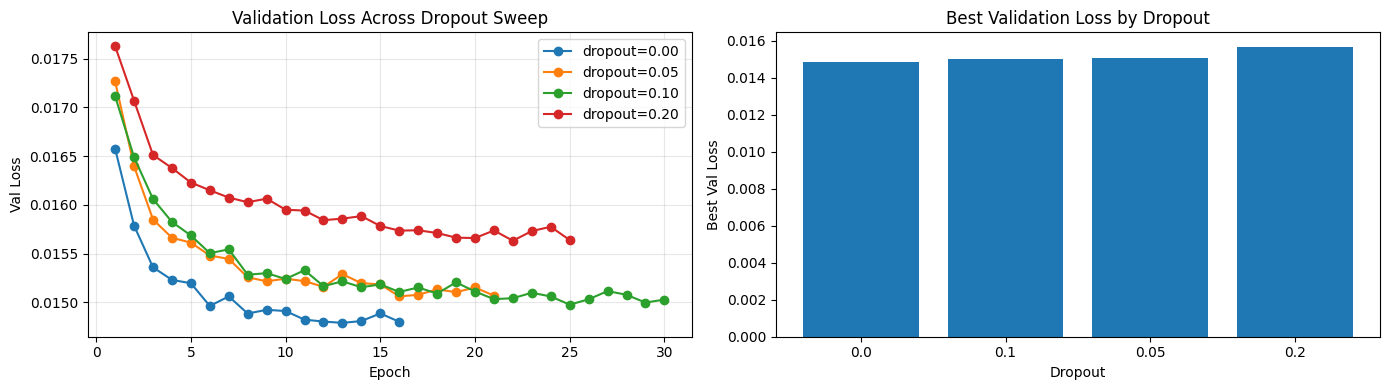

Selected dropout for downstream evaluation: 0.00


,epoch,train_loss,val_loss
11,12,0.014778,0.014805
12,13,0.014759,0.014791
13,14,0.014750,0.014810
14,15,0.014740,0.014888
15,16,0.014714,0.014802


In [15]:
history_path = output_dir / "history.json"

if "history" in globals() and history:
    history_df = pd.DataFrame(history)
else:
    with history_path.open("r", encoding="utf-8") as f:
        history_df = pd.DataFrame(json.load(f))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for dropout_prob, run_history in sweep_histories.items():
    run_history_df = pd.DataFrame(run_history)
    axes[0].plot(run_history_df["epoch"], run_history_df["val_loss"], marker="o", label=f"dropout={dropout_prob:.2f}")

axes[0].set_title("Validation Loss Across Dropout Sweep")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Val Loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].bar(sweep_results_df["dropout_prob"].astype(str), sweep_results_df["best_val_loss"])
axes[1].set_title("Best Validation Loss by Dropout")
axes[1].set_xlabel("Dropout")
axes[1].set_ylabel("Best Val Loss")

plt.tight_layout()
plt.show()

print(f"Selected dropout for downstream evaluation: {best_dropout:.2f}")
history_df.tail()


In [16]:
base_output_dir.mkdir(parents=True, exist_ok=True)

sweep_summary = {
    "selected_dropout": best_dropout,
    "selected_output_dir": str(output_dir.relative_to(REPO_ROOT)),
    "selection_metric": "best_val_loss",
    "runs": sweep_results_df.to_dict(orient="records"),
}

sweep_results_df.to_csv(base_output_dir / "dropout_sweep_results.csv", index=False)
with (base_output_dir / "dropout_sweep_summary.json").open("w", encoding="utf-8") as handle:
    json.dump(sweep_summary, handle, indent=2)

print(f"Saved sweep outputs to {base_output_dir}")
print(f"Selected run directory: {output_dir}")
sweep_summary


Saved sweep outputs to C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x64\autoencoder_batchnorm_dropout
Selected run directory: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x64\autoencoder_batchnorm_dropout\dropout_0p00


{'selected_dropout': 0.0,
 'selected_output_dir': 'artifacts\\x64\\autoencoder_batchnorm_dropout\\dropout_0p00',
 'selection_metric': 'best_val_loss',
 'runs': [{'dropout_prob': 0.0,
   'best_epoch': 11,
   'best_val_loss': 0.014823875755071641,
   'epochs_ran': 16,
   'output_dir': 'artifacts\\x64\\autoencoder_batchnorm_dropout\\dropout_0p00'},
  {'dropout_prob': 0.1,
   'best_epoch': 25,
   'best_val_loss': 0.014977806612849236,
   'epochs_ran': 30,
   'output_dir': 'artifacts\\x64\\autoencoder_batchnorm_dropout\\dropout_0p10'},
  {'dropout_prob': 0.05,
   'best_epoch': 16,
   'best_val_loss': 0.015062548857927323,
   'epochs_ran': 21,
   'output_dir': 'artifacts\\x64\\autoencoder_batchnorm_dropout\\dropout_0p05'},
  {'dropout_prob': 0.2,
   'best_epoch': 20,
   'best_val_loss': 0.01566036829352379,
   'epochs_ran': 25,
   'output_dir': 'artifacts\\x64\\autoencoder_batchnorm_dropout\\dropout_0p20'}]}

In [17]:
best_model_path = output_dir / "best_model.pt"
if best_model_path.exists():
    best_checkpoint = torch.load(best_model_path, map_location=device)
    model.load_state_dict(best_checkpoint["model_state_dict"])
    print(f"Loaded best_model.pt from epoch {best_checkpoint.get('best_epoch', 'unknown')}")
else:
    print("best_model.pt not found. Using current in-memory model state.")

model.eval()

def reconstruction_error(inputs: torch.Tensor, outputs: torch.Tensor, score_name: str = ANOMALY_SCORE_NAME) -> torch.Tensor:
    if score_name == "mse_mean":
        return spatial_mean(squared_error_map(inputs, outputs))
    if score_name == "topk_abs_mean":
        return topk_spatial_mean(absolute_error_map(inputs, outputs), topk_ratio=TOPK_RATIO)
    raise ValueError(f"Unsupported score_name: {score_name}")

test_rows = metadata[metadata["split"] == "test"].reset_index(drop=True)
test_scores = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        scores = reconstruction_error(inputs, outputs, score_name=ANOMALY_SCORE_NAME).cpu().numpy()
        labels = labels.cpu().numpy()
        for score, label in zip(scores, labels):
            test_scores.append({"score": float(score), "is_anomaly": int(label)})

score_df = pd.DataFrame(test_scores)
print({"evaluation_score": ANOMALY_SCORE_NAME, "topk_ratio": TOPK_RATIO if ANOMALY_SCORE_NAME == "topk_abs_mean" else None})
score_df.head()

Loaded best_model.pt from epoch 11
{'evaluation_score': 'topk_abs_mean', 'topk_ratio': 0.01}


,score,is_anomaly
0,0.480280,0
1,0.562477,0
2,0.476540,0
3,0.503094,0
4,0.471366,0


In [19]:
val_scores = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        scores = reconstruction_error(inputs, outputs, score_name=ANOMALY_SCORE_NAME).cpu().numpy()
        val_scores.extend(scores.tolist())

val_score_series = pd.Series(val_scores, name="val_score")
threshold = float(val_score_series.quantile(0.95))
print(f"Chosen threshold from validation normals (95th percentile, {ANOMALY_SCORE_NAME}): {threshold:.6f}")
val_score_series.describe()

Chosen threshold from validation normals (95th percentile, topk_abs_mean): 0.531021


count    5000.000000
mean        0.483334
std         0.024448
min         0.293564
25%         0.472408
50%         0.482641
75%         0.489837
max         0.721308
Name: val_score, dtype: float64

In [20]:
score_df["predicted_anomaly"] = (score_df["score"] > threshold).astype(int)

precision = precision_score(score_df["is_anomaly"], score_df["predicted_anomaly"], zero_division=0)
recall = recall_score(score_df["is_anomaly"], score_df["predicted_anomaly"], zero_division=0)
f1 = f1_score(score_df["is_anomaly"], score_df["predicted_anomaly"], zero_division=0)
auroc = roc_auc_score(score_df["is_anomaly"], score_df["score"])
auprc = average_precision_score(score_df["is_anomaly"], score_df["score"])
cm = confusion_matrix(score_df["is_anomaly"], score_df["predicted_anomaly"])

metrics_df = pd.DataFrame(
    [
        {"metric": "score_name", "value": ANOMALY_SCORE_NAME},
        {"metric": "precision", "value": precision},
        {"metric": "recall", "value": recall},
        {"metric": "f1", "value": f1},
        {"metric": "auroc", "value": auroc},
        {"metric": "auprc", "value": auprc},
        {"metric": "threshold", "value": threshold},
    ]
)

display(metrics_df)
display(pd.DataFrame(cm, index=["true_normal", "true_anomaly"], columns=["pred_normal", "pred_anomaly"]))

,metric,value
0,score_name,topk_abs_mean
1,precision,0.350365
2,recall,0.576
3,f1,0.435703
4,auroc,0.799805
5,auprc,0.602296
6,threshold,0.531021


,pred_normal,pred_anomaly
true_normal,4733,267
true_anomaly,106,144


,threshold,precision,recall,f1,predicted_anomalies
5103,0.610241,0.935252,0.520,0.668380,138
5105,0.619368,0.941606,0.516,0.666667,136
5102,0.609741,0.928571,0.520,0.666667,139
5101,0.609670,0.921986,0.520,0.664962,140
5104,0.614062,0.934783,0.516,0.664948,137
5100,0.609185,0.915493,0.520,0.663265,141
5106,0.620712,0.941176,0.512,0.663212,135
5099,0.608083,0.909091,0.520,0.661578,142
5098,0.606473,0.902778,0.520,0.659898,143
5107,0.624404,0.940741,0.508,0.659740,134


Best F1 threshold: 0.610241 | precision=0.9353, recall=0.5200, f1=0.6684


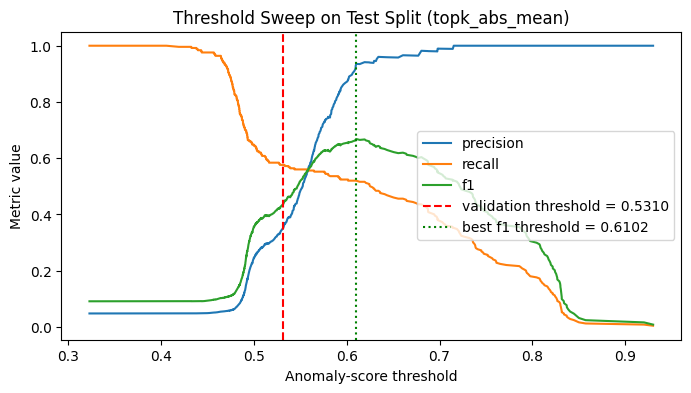

In [21]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    score_df["is_anomaly"],
    score_df["score"],
)

threshold_sweep_df = pd.DataFrame(
    {
        "threshold": pr_thresholds,
        "precision": precision_curve[:-1],
        "recall": recall_curve[:-1],
    }
)

threshold_sweep_df["f1"] = (
    2
    * threshold_sweep_df["precision"]
    * threshold_sweep_df["recall"]
    / (threshold_sweep_df["precision"] + threshold_sweep_df["recall"] + 1e-12)
)

threshold_sweep_df["predicted_anomalies"] = [
    int((score_df["score"] > t).sum()) for t in threshold_sweep_df["threshold"]
]

best_f1_row = threshold_sweep_df.loc[threshold_sweep_df["f1"].idxmax()]

display(threshold_sweep_df.sort_values("f1", ascending=False).head(10))
print(
    f"Best F1 threshold: {best_f1_row['threshold']:.6f} | "
    f"precision={best_f1_row['precision']:.4f}, recall={best_f1_row['recall']:.4f}, f1={best_f1_row['f1']:.4f}"
)

plt.figure(figsize=(8, 4))
plt.plot(threshold_sweep_df["threshold"], threshold_sweep_df["precision"], label="precision")
plt.plot(threshold_sweep_df["threshold"], threshold_sweep_df["recall"], label="recall")
plt.plot(threshold_sweep_df["threshold"], threshold_sweep_df["f1"], label="f1")
plt.axvline(threshold, color="red", linestyle="--", label=f"validation threshold = {threshold:.4f}")
plt.axvline(best_f1_row["threshold"], color="green", linestyle=":", label=f"best f1 threshold = {best_f1_row['threshold']:.4f}")
plt.xlabel("Anomaly-score threshold")
plt.ylabel("Metric value")
plt.title(f"Threshold Sweep on Test Split ({ANOMALY_SCORE_NAME})")
plt.legend()
plt.show()


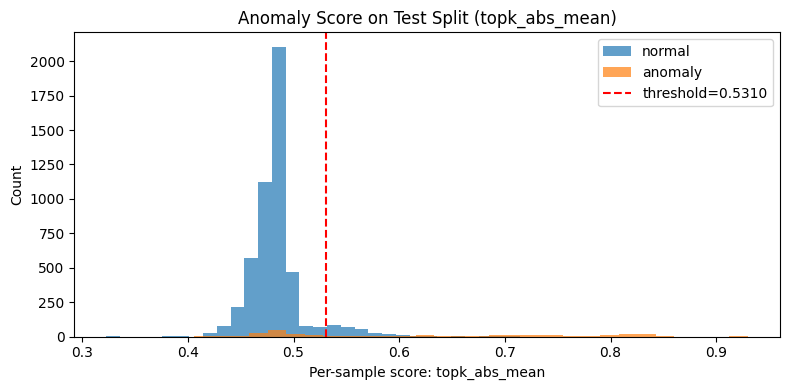

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(score_df[score_df["is_anomaly"] == 0]["score"], bins=30, alpha=0.7, label="normal")
ax.hist(score_df[score_df["is_anomaly"] == 1]["score"], bins=30, alpha=0.7, label="anomaly")
ax.axvline(threshold, color="red", linestyle="--", label=f"threshold={threshold:.4f}")
ax.set_title(f"Anomaly Score on Test Split ({ANOMALY_SCORE_NAME})")
ax.set_xlabel(f"Per-sample score: {ANOMALY_SCORE_NAME}")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()

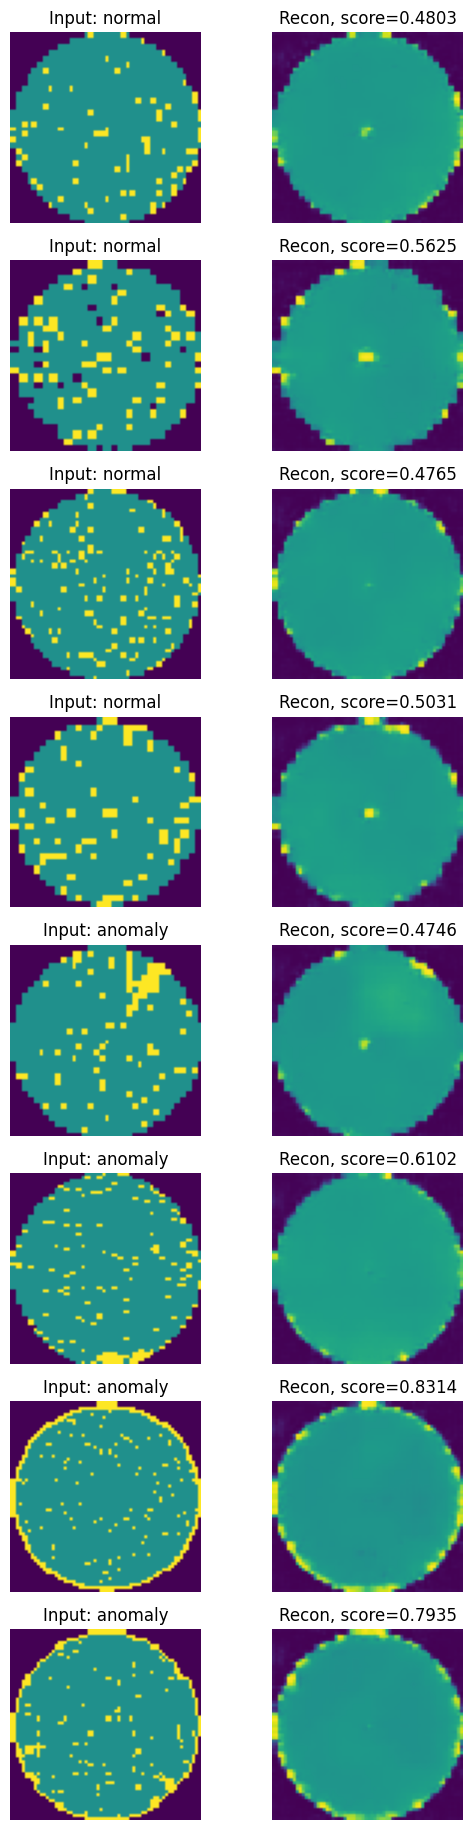

In [23]:
normal_test_idx = score_df[score_df["is_anomaly"] == 0].index[:4].tolist()
anomaly_test_idx = score_df[score_df["is_anomaly"] == 1].index[:4].tolist()
selected_indices = normal_test_idx + anomaly_test_idx

fig, axes = plt.subplots(len(selected_indices), 2, figsize=(6, 2.3 * len(selected_indices)))

with torch.no_grad():
    for row_idx, sample_idx in enumerate(selected_indices):
        input_tensor, label = test_dataset[sample_idx]
        output_tensor = model(input_tensor.unsqueeze(0).to(device)).squeeze(0).cpu()
        title_prefix = "anomaly" if int(label) == 1 else "normal"
        score = score_df.iloc[sample_idx]["score"]

        axes[row_idx, 0].imshow(input_tensor.squeeze(0), cmap="viridis")
        axes[row_idx, 0].set_title(f"Input: {title_prefix}")
        axes[row_idx, 0].axis("off")

        axes[row_idx, 1].imshow(output_tensor.squeeze(0), cmap="viridis")
        axes[row_idx, 1].set_title(f"Recon, score={score:.4f}")
        axes[row_idx, 1].axis("off")

plt.tight_layout()

## Failure Analysis

This section inspects the current autoencoder run using the selected main score.

Purpose:
- identify representative false positives, false negatives, true positives, and true negatives
- attach `defect_type` metadata when available
- decide whether the next change should target scoring, capacity, or model class


In [24]:
analysis_df = test_dataset.metadata.reset_index(drop=True).copy()
analysis_df = pd.concat(
    [analysis_df, score_df[["score", "predicted_anomaly"]].reset_index(drop=True)],
    axis=1,
)

analysis_df["error_type"] = "tn"
analysis_df.loc[(analysis_df["is_anomaly"] == 0) & (analysis_df["predicted_anomaly"] == 1), "error_type"] = "fp"
analysis_df.loc[(analysis_df["is_anomaly"] == 1) & (analysis_df["predicted_anomaly"] == 0), "error_type"] = "fn"
analysis_df.loc[(analysis_df["is_anomaly"] == 1) & (analysis_df["predicted_anomaly"] == 1), "error_type"] = "tp"
analysis_df["correct"] = analysis_df["is_anomaly"] == analysis_df["predicted_anomaly"]

error_summary_df = (
    analysis_df.groupby("error_type")
    .agg(count=("error_type", "size"), mean_score=("score", "mean"))
    .reindex(["tp", "fn", "fp", "tn"])
)

defect_recall_df = (
    analysis_df[analysis_df["is_anomaly"] == 1]
    .groupby("defect_type")
    .agg(
        count=("defect_type", "size"),
        detected=("predicted_anomaly", "sum"),
        mean_score=("score", "mean"),
    )
    .sort_values(["detected", "count"], ascending=[False, False])
)
defect_recall_df["recall"] = defect_recall_df["detected"] / defect_recall_df["count"]

fp_defect_df = (
    analysis_df[analysis_df["error_type"] == "fp"]
    .groupby("defect_type")
    .agg(count=("defect_type", "size"), mean_score=("score", "mean"))
    .sort_values(["count", "mean_score"], ascending=[False, False])
)

display(error_summary_df)
display(defect_recall_df)
display(fp_defect_df)

analysis_df.head()


,count,mean_score
error_type,,
tp,144,0.733711
fn,106,0.482951
fp,267,0.560003
tn,4733,0.479104


,count,detected,mean_score,recall
defect_type,,,,
Edge-Ring,84,70,0.745212,0.833333
Center,50,36,0.619991,0.720000
Edge-Loc,53,21,0.566298,0.396226
Loc,34,7,0.506538,0.205882
Scratch,15,3,0.513673,0.200000
Random,5,3,0.591363,0.600000
Donut,7,2,0.557917,0.285714
Near-full,2,2,0.723285,1.000000


,count,mean_score
defect_type,,
none,267,0.560003


,array_path,label,defect_type,is_anomaly,split,source_split,original_height,original_width,score,predicted_anomaly,error_type,correct
0,data/processed/x64/wm811k/arrays/wafer_0045000...,none,none,0,test,Training,33,37,0.480280,0,tn,True
1,data/processed/x64/wm811k/arrays/wafer_0045001...,none,none,0,test,Training,27,25,0.562477,1,fp,False
2,data/processed/x64/wm811k/arrays/wafer_0045002...,none,none,0,test,Test,41,42,0.476540,0,tn,True
3,data/processed/x64/wm811k/arrays/wafer_0045003...,none,none,0,test,Training,27,27,0.503094,0,tn,True
4,data/processed/x64/wm811k/arrays/wafer_0045004...,none,none,0,test,Test,30,34,0.471366,0,tn,True


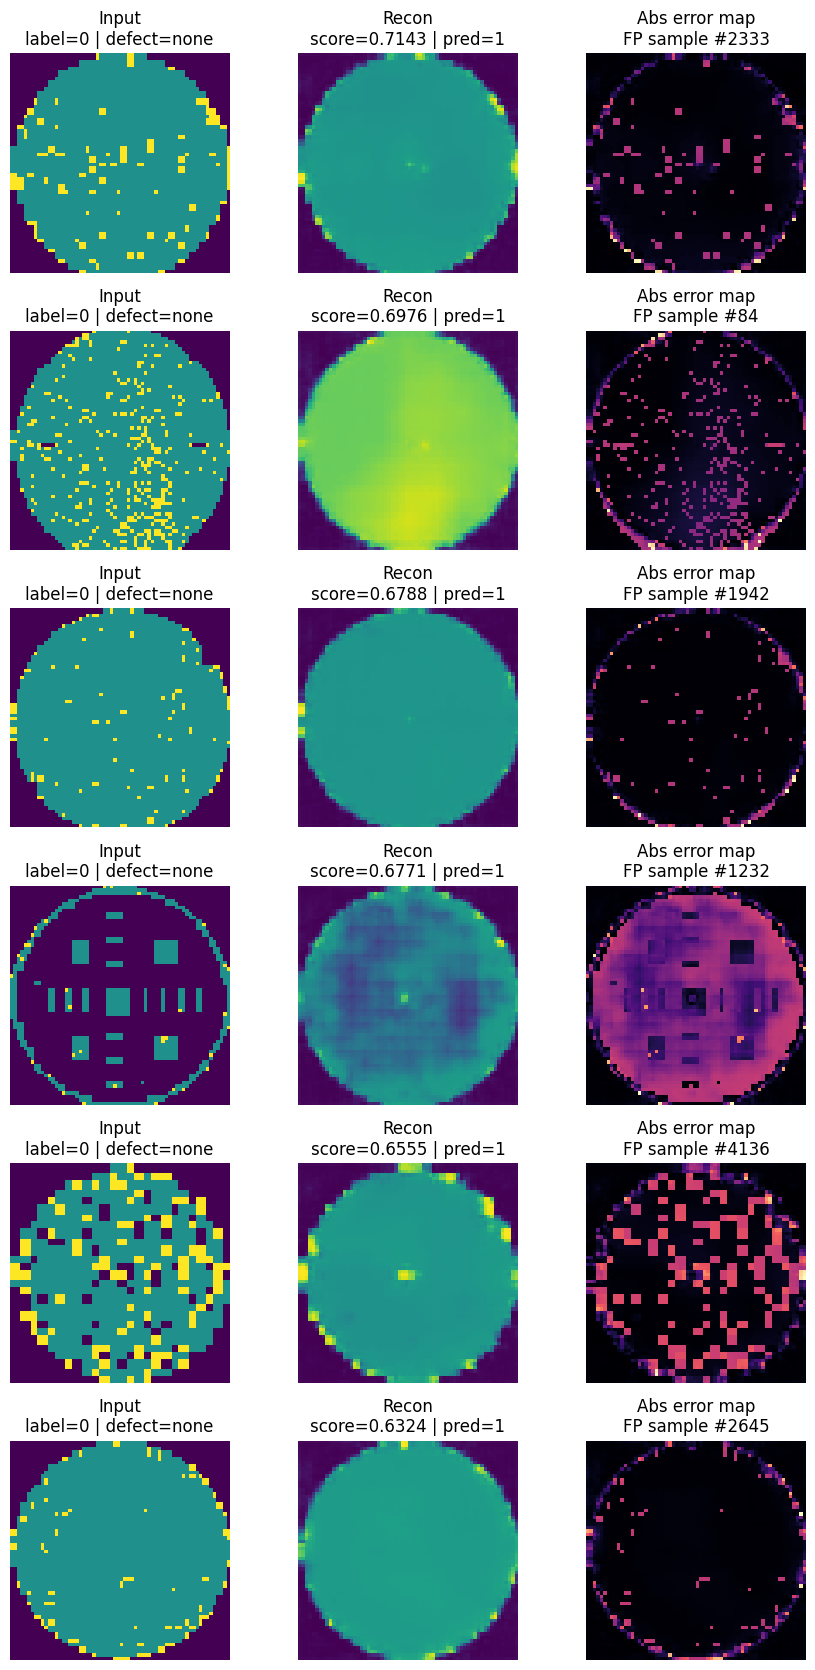

,defect_type,score,predicted_anomaly,error_type
2333,none,0.714275,1,fp
84,none,0.697633,1,fp
1942,none,0.678785,1,fp
1232,none,0.677141,1,fp
4136,none,0.655549,1,fp
2645,none,0.632386,1,fp


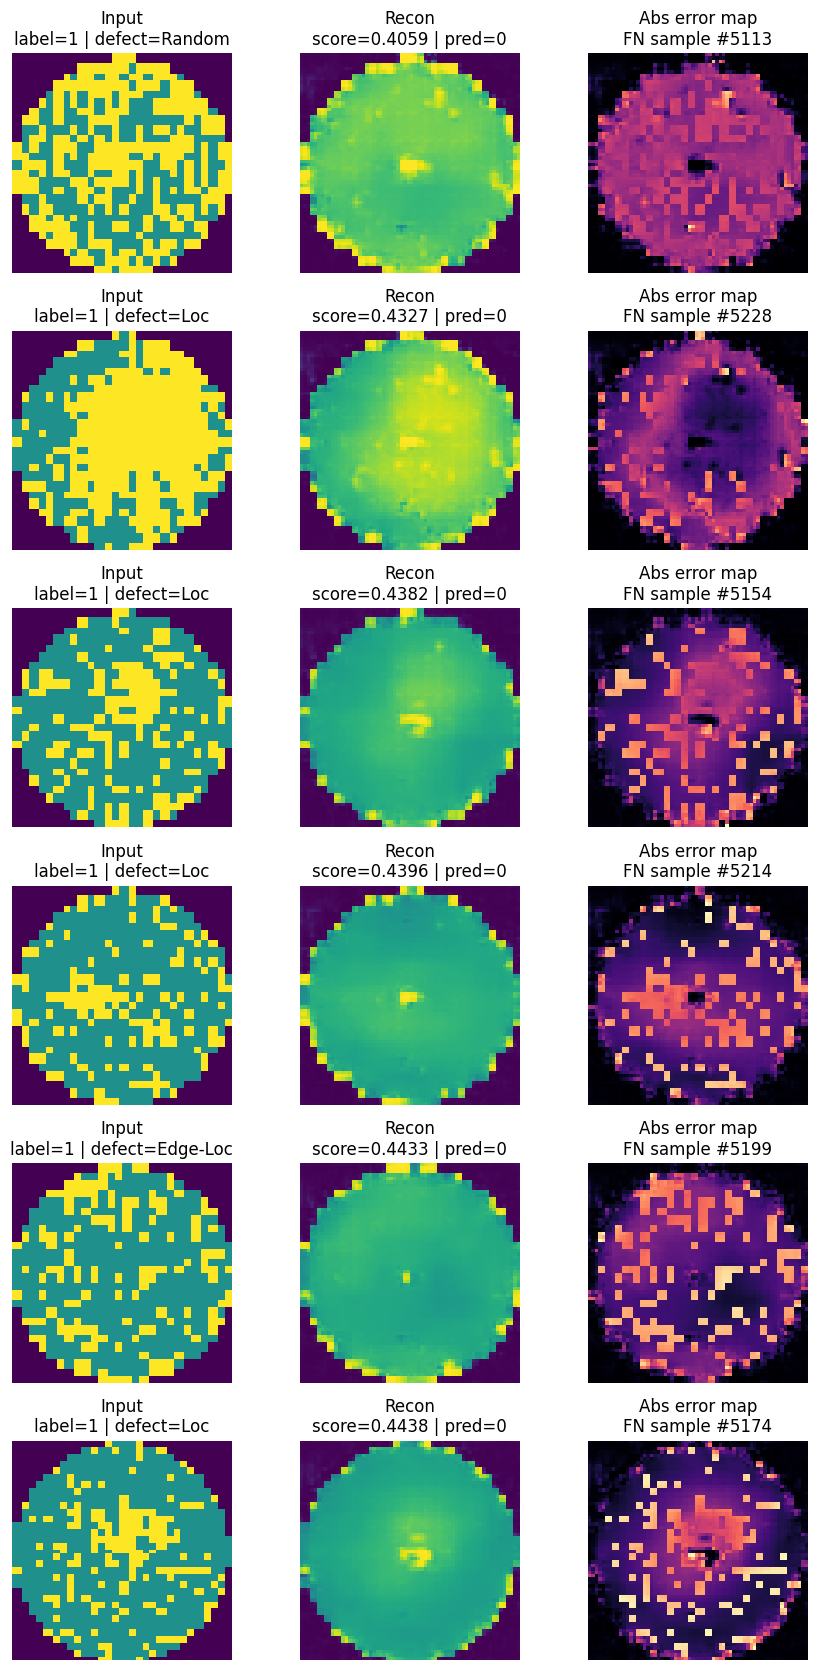

,defect_type,score,predicted_anomaly,error_type
5113,Random,0.405850,0,fn
5228,Loc,0.432656,0,fn
5154,Loc,0.438234,0,fn
5214,Loc,0.439574,0,fn
5199,Edge-Loc,0.443286,0,fn
5174,Loc,0.443756,0,fn


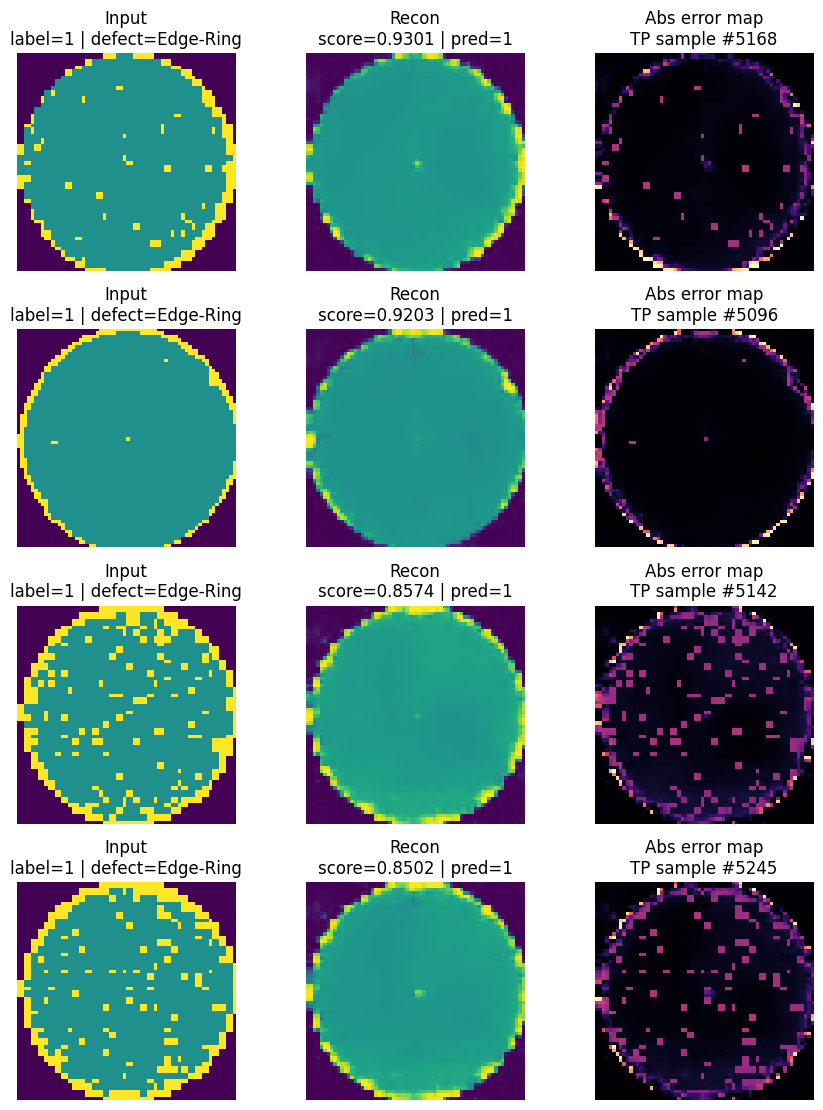

,defect_type,score,predicted_anomaly,error_type
5168,Edge-Ring,0.930065,1,tp
5096,Edge-Ring,0.920257,1,tp
5142,Edge-Ring,0.857415,1,tp
5245,Edge-Ring,0.850151,1,tp


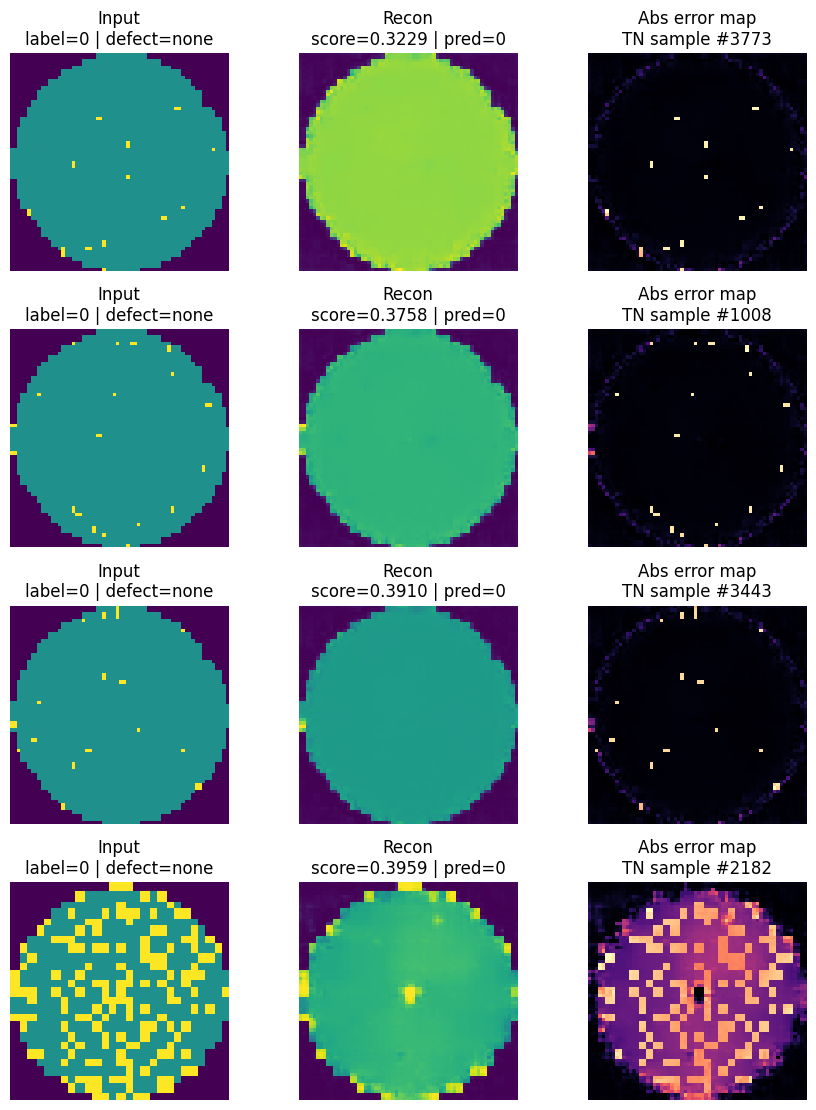

,defect_type,score,predicted_anomaly,error_type
3773,none,0.322948,0,tn
1008,none,0.375784,0,tn
3443,none,0.391040,0,tn
2182,none,0.395915,0,tn


In [25]:
def show_error_examples(error_type: str, n_examples: int = 6, score_order: str = "desc") -> pd.DataFrame:
    subset = analysis_df[analysis_df["error_type"] == error_type].copy()
    if subset.empty:
        print(f"No samples found for error_type={error_type!r}.")
        return subset

    ascending = score_order == "asc"
    subset = subset.sort_values("score", ascending=ascending).head(n_examples)
    fig, axes = plt.subplots(len(subset), 3, figsize=(9, 2.8 * len(subset)))
    if len(subset) == 1:
        axes = np.expand_dims(axes, axis=0)

    with torch.no_grad():
        for row_idx, (sample_idx, row) in enumerate(subset.iterrows()):
            input_tensor, label = test_dataset[sample_idx]
            output_tensor = model(input_tensor.unsqueeze(0).to(device)).squeeze(0).cpu()
            error_map = absolute_error_map(input_tensor.unsqueeze(0), output_tensor.unsqueeze(0)).squeeze(0).squeeze(0).cpu()

            axes[row_idx, 0].imshow(input_tensor.squeeze(0), cmap="viridis")
            axes[row_idx, 0].set_title(
                f"Input\nlabel={int(label)} | defect={row.get('defect_type', 'unknown')}"
            )
            axes[row_idx, 0].axis("off")

            axes[row_idx, 1].imshow(output_tensor.squeeze(0), cmap="viridis")
            axes[row_idx, 1].set_title(
                f"Recon\nscore={row['score']:.4f} | pred={row['predicted_anomaly']}"
            )
            axes[row_idx, 1].axis("off")

            axes[row_idx, 2].imshow(error_map, cmap="magma")
            axes[row_idx, 2].set_title(f"Abs error map\n{error_type.upper()} sample #{sample_idx}")
            axes[row_idx, 2].axis("off")

    plt.tight_layout()
    plt.show()
    return subset[["defect_type", "score", "predicted_anomaly", "error_type"]]


display(show_error_examples("fp", n_examples=6, score_order="desc"))
display(show_error_examples("fn", n_examples=6, score_order="asc"))
display(show_error_examples("tp", n_examples=4, score_order="desc"))
display(show_error_examples("tn", n_examples=4, score_order="asc"))


## Score Ablation

This section is separate from the main autoencoder experiment above.

Purpose:
- keep the current best `64x64` autoencoder checkpoint fixed
- compare multiple anomaly scoring rules without retraining
- identify whether scoring is the bottleneck before changing the model


In [26]:
import subprocess

score_ablation_output_root = output_dir
score_ablation_best_model_path = score_ablation_output_root / "best_model.pt"
if not score_ablation_best_model_path.exists():
    raise FileNotFoundError(
        f"Best autoencoder checkpoint not found: {score_ablation_best_model_path}. "
        "You do not need to retrain if the checkpoint already exists, but the file must be present."
    )

score_ablation_output_dir = score_ablation_output_root / "score_ablation"
score_ablation_output_dir.mkdir(parents=True, exist_ok=True)

score_ablation_cmd = [
    sys.executable,
    "scripts/evaluate_autoencoder_scores.py",
    "--checkpoint",
    str(score_ablation_best_model_path.relative_to(REPO_ROOT)),
    "--config",
    str(CONFIG_PATH.relative_to(REPO_ROOT)),
    "--output-dir",
    str(score_ablation_output_dir.relative_to(REPO_ROOT)),
]

print("Running:")
print(" ".join(score_ablation_cmd))

subprocess.run(score_ablation_cmd, cwd=REPO_ROOT, check=True)


Running:
c:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\venv\Scripts\python.exe scripts/evaluate_autoencoder_scores.py --checkpoint artifacts\x64\autoencoder_batchnorm_dropout\dropout_0p00\best_model.pt --config configs\training\train_autoencoder_batchnorm_dropout.toml --output-dir artifacts\x64\autoencoder_batchnorm_dropout\dropout_0p00\score_ablation


CompletedProcess(args=['c:\\Users\\User\\Desktop\\Term 8\\Deep Learning\\Project\\DeepLearning-Group8\\venv\\Scripts\\python.exe', 'scripts/evaluate_autoencoder_scores.py', '--checkpoint', 'artifacts\\x64\\autoencoder_batchnorm_dropout\\dropout_0p00\\best_model.pt', '--config', 'configs\\training\\train_autoencoder_batchnorm_dropout.toml', '--output-dir', 'artifacts\\x64\\autoencoder_batchnorm_dropout\\dropout_0p00\\score_ablation'], returncode=0)

In [27]:
score_ablation_df = pd.read_csv(score_ablation_output_dir / "score_summary.csv")
score_ablation_summary = json.loads((score_ablation_output_dir / "score_summary.json").read_text(encoding="utf-8"))

display(score_ablation_df)
score_ablation_summary

,score_name,threshold,val_threshold_precision,val_threshold_recall,val_threshold_f1,auroc,auprc,best_sweep_threshold,best_sweep_precision,best_sweep_recall,best_sweep_f1
0,max_abs,0.753411,0.393120,0.640,0.487062,0.850790,0.616946,0.962055,0.879195,0.524,0.656642
1,topk_abs_mean,0.531021,0.350365,0.576,0.435703,0.799805,0.602296,0.610241,0.935252,0.520,0.668380
2,mse_mean,0.025543,0.284530,0.412,0.336601,0.784481,0.343180,0.028238,0.469613,0.340,0.394432
3,foreground_mse,0.032325,0.230556,0.332,0.272131,0.734939,0.263042,0.036951,0.432836,0.232,0.302083
4,mae_mean,0.104804,0.215847,0.316,0.256494,0.727365,0.262883,0.117583,0.421053,0.256,0.318408
5,pooled_mae_mean,0.103529,0.212707,0.308,0.251634,0.721275,0.256669,0.113285,0.361702,0.272,0.310502
6,foreground_mae,0.132212,0.205279,0.280,0.236887,0.694310,0.228523,0.146660,0.349693,0.228,0.276029


{'checkpoint': 'artifacts\\x64\\autoencoder_batchnorm_dropout\\dropout_0p00\\best_model.pt',
 'topk_ratio': 0.01,
 'foreground_threshold': 0.0,
 'pool_kernel_size': 5,
 'threshold_quantile': 0.95,
 'scores': [{'score_name': 'max_abs',
   'threshold': 0.7534114211797717,
   'val_threshold_precision': 0.3931203931203931,
   'val_threshold_recall': 0.64,
   'val_threshold_f1': 0.487062404870624,
   'auroc': 0.8507904,
   'auprc': 0.6169462429239511,
   'best_sweep_threshold': 0.9620553851127625,
   'best_sweep_precision': 0.8791946308724832,
   'best_sweep_recall': 0.524,
   'best_sweep_f1': 0.6566416040095571},
  {'score_name': 'topk_abs_mean',
   'threshold': 0.5310211390256881,
   'val_threshold_precision': 0.35036496350364965,
   'val_threshold_recall': 0.576,
   'val_threshold_f1': 0.4357034795763994,
   'auroc': 0.7998048,
   'auprc': 0.6022964144743493,
   'best_sweep_threshold': 0.6102414727210999,
   'best_sweep_precision': 0.935251798561151,
   'best_sweep_recall': 0.52,
   'bes

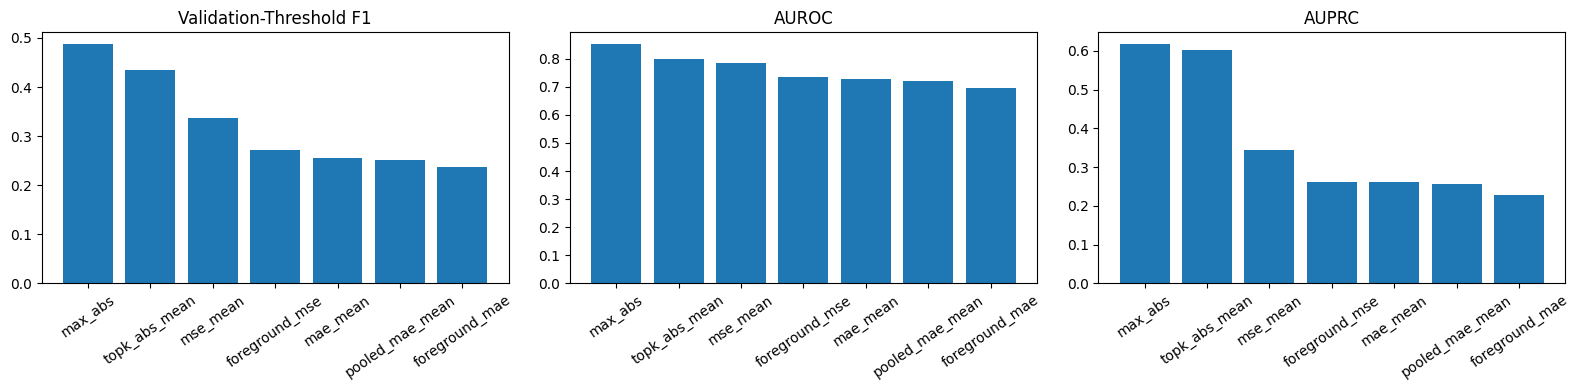

,score_name,val_threshold_f1,auroc,auprc,best_sweep_f1
0,max_abs,0.487062,0.850790,0.616946,0.656642
1,topk_abs_mean,0.435703,0.799805,0.602296,0.668380
2,mse_mean,0.336601,0.784481,0.343180,0.394432
3,foreground_mse,0.272131,0.734939,0.263042,0.302083
4,mae_mean,0.256494,0.727365,0.262883,0.318408
5,pooled_mae_mean,0.251634,0.721275,0.256669,0.310502
6,foreground_mae,0.236887,0.694310,0.228523,0.276029


In [28]:
top_scores = score_ablation_df.sort_values("val_threshold_f1", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(top_scores["score_name"], top_scores["val_threshold_f1"])
axes[0].set_title("Validation-Threshold F1")
axes[0].tick_params(axis="x", rotation=35)

axes[1].bar(top_scores["score_name"], top_scores["auroc"])
axes[1].set_title("AUROC")
axes[1].tick_params(axis="x", rotation=35)

axes[2].bar(top_scores["score_name"], top_scores["auprc"])
axes[2].set_title("AUPRC")
axes[2].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

top_scores[["score_name", "val_threshold_f1", "auroc", "auprc", "best_sweep_f1"]]